# Graph slicing using centrality measures



[!!! add bibliography and links to Pajek notebooks]

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
import pprint as pprint

In [2]:
# https://networkx.org/documentation/stable/install.html
import networkx as nx

#### https://ipycytoscape.readthedocs.io/en/latest/installing.html
# import ipycytoscape as cy

In [3]:
import sys
from importlib import reload

# Add parent directory to the path
sys.path.insert(0, '..')

### If you want to add the parent-parent directory,
sys.path.insert(0, '../..')

In [4]:
import network_analysis_functions as naf

In [5]:
print(reload(naf))

<module 'network_analysis_functions' from '/home/francesco/kDrive/python_notebooks/sciences_historiques_numeriques/histoire_numerique_methodes/analyse_reseaux/network_analysis_functions.py'>


## NetworkX Core Number Function

The core_number function in NetworkX is used to find the core number of each node in a graph. The core number of a node is the largest k such that the node is in the k-core of the graph.
Definition of Core Number

The core number of a node is a measure of its centrality and importance in the graph. It is defined as the largest k such that the node is in the k-core of the graph. The k-core of a graph is the subgraph of nodes that have a degree of at least k.

In [6]:
# Create a simple graph
G = nx.Graph()
G.add_edges_from([
    ('a', 'b'),
    ('a', 'c'),
    ('b', 'c'),
    ('c', 'd'),
    ('d', 'e'),
    ('e', 'f')
])

naf.basic_graph_properties(G)


{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 6,
 'number_of_edges': 6,
 '------': '------',
 'is connected': True,
 'components': 1,
 'density': 0.4}


Core numbers:  {'a': 2, 'b': 2, 'c': 2, 'd': 1, 'e': 1, 'f': 1}
Node colors:  [2, 2, 2, 1, 1, 1]


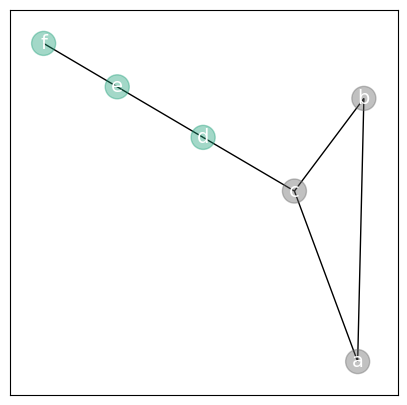

In [7]:

# Find the core number of each node
core_numbers = nx.core_number(G)
print('Core numbers: ', core_numbers)

plt.figure(figsize = (5,5))

# Visualize the graph with node colors based on core numbers
pos = nx.spring_layout(G)
colors = [core_numbers[node] for node in G.nodes()]
print('Node colors: ', colors)

### https://matplotlib.org/stable/users/explain/colors/colormaps.html
nx.draw_networkx_nodes(G, pos, node_color=colors, cmap=plt.get_cmap('Dark2'), alpha=0.4, node_size=300)
nx.draw_networkx_labels(G,pos,font_color='white', font_size=14)
nx.draw_networkx_edges(G, pos)
plt.show()

## Community Detection using Core Number

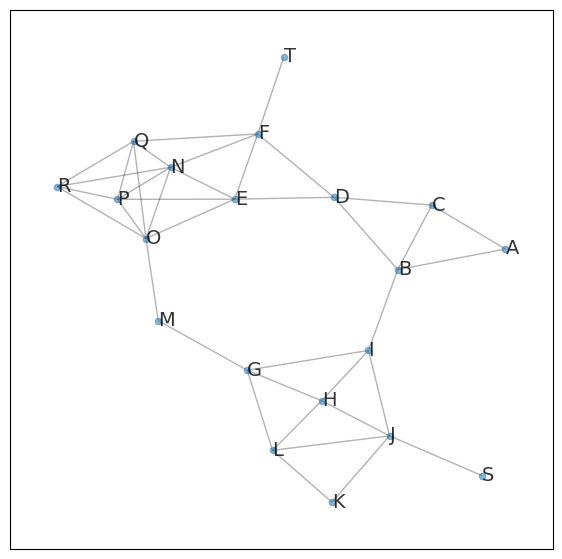

In [8]:

# Create a sample graph with some communities

l = [
        ('A', 'B'), ('A', 'C'), ('B', 'C'), ('B', 'D'), ('C', 'D'), ('D', 'E'), 
        ('D', 'F'), ('E', 'F'), ('E', 'P'), ('E', 'N'), ('E', 'O'), 
        ('F', 'T'),('F', 'Q'),('G', 'H'), ('G', 'I'), 
        ('G', 'L'), ('G', 'M'), ('H', 'I'), ('H', 'J'), ('H', 'L'), ('I', 'B'), 
        ('I', 'J'), ('J', 'K'), ('J', 'L'), ('J', 'S'), ('K', 'L'), ('M', 'O'), ('O', 'R'), 
        ('N', 'F'), ('N', 'O'), ('N', 'P'), ('N', 'Q'), ('N', 'R'), ('O', 'P'), ('O', 'Q'),
        ('P', 'Q'), ('P', 'R'), ('Q', 'R')]


G = nx.Graph()
G.add_edges_from(l)


plt.figure(figsize=(7,7))

pos=nx.kamada_kawai_layout(G)
#pos=nx.spring_layout(G, k=0.5)

nx.draw_networkx_nodes(G, pos, node_size=20,alpha=0.5)
nx.draw_networkx_edges(G, pos, alpha=0.3)
nx.draw_networkx_labels(G, pos, horizontalalignment='left', font_size=14, alpha=0.8)
plt.show()


### Degrees and their distribution

In [9]:
ld = list(nx.degree(G))
pprint.pprint(sorted(ld, key=lambda tup: tup[1], reverse=True))


[('N', 6),
 ('O', 6),
 ('E', 5),
 ('F', 5),
 ('P', 5),
 ('Q', 5),
 ('J', 5),
 ('B', 4),
 ('D', 4),
 ('G', 4),
 ('H', 4),
 ('I', 4),
 ('L', 4),
 ('R', 4),
 ('C', 3),
 ('A', 2),
 ('M', 2),
 ('K', 2),
 ('T', 1),
 ('S', 1)]


count    20.000000
mean      3.800000
std       1.507874
min       1.000000
25%       2.750000
50%       4.000000
75%       5.000000
max       6.000000
dtype: float64


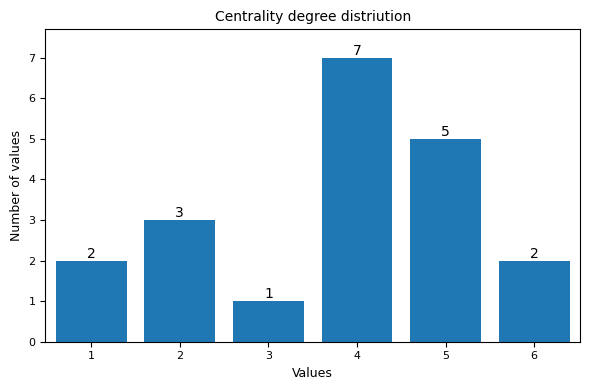

In [10]:
d = [d[1] for d in ld]
naf.describe_plot_integers_distribution(d, 6, 4, 'Centrality degree distriution')

[('A', 0.10526315789473684), ('B', 0.21052631578947367), ('C', 0.15789473684210525), ('D', 0.21052631578947367), ('E', 0.2631578947368421), ('F', 0.2631578947368421), ('P', 0.2631578947368421), ('N', 0.3157894736842105), ('O', 0.3157894736842105), ('T', 0.05263157894736842), ('Q', 0.2631578947368421), ('G', 0.21052631578947367), ('H', 0.21052631578947367), ('I', 0.21052631578947367), ('L', 0.21052631578947367), ('M', 0.10526315789473684), ('J', 0.2631578947368421), ('K', 0.10526315789473684), ('S', 0.05263157894736842), ('R', 0.21052631578947367)]


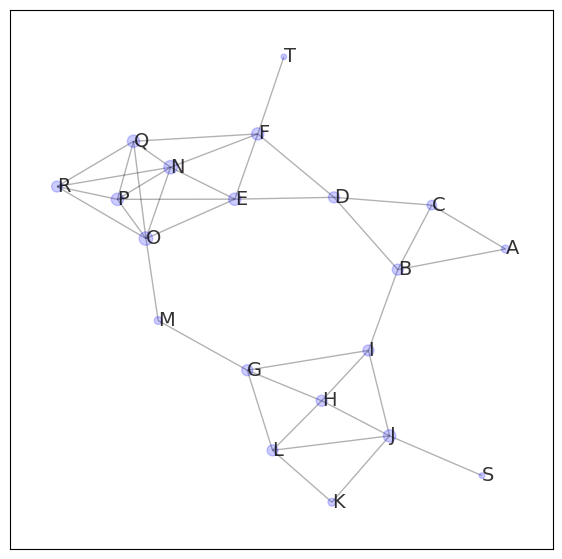

In [46]:

plt.figure(figsize=(7,7))
pos=nx.kamada_kawai_layout(G)
#pos=nx.spring_layout(G, k=0.5)

ld = list(nx.degree(G))
size_ld = [n[1]*20 for n in ld]

### The degree centrality for a node v is the fraction of nodes it is connected to.
# https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.centrality.degree_centrality.html
ldc = list(nx.degree_centrality(G).items())
size_ldc = [n[1]*300 for n in ldc]
print(ldc)


### https://matplotlib.org/stable/users/explain/colors/colormaps.html
nx.draw_networkx_nodes(G, pos, node_color='blue', node_size=size_ldc, alpha=0.2)
nx.draw_networkx_edges(G, pos, alpha=0.3)
nx.draw_networkx_labels(G, pos, horizontalalignment='left', font_size=14, alpha=0.8)
plt.show()


### Core numbers

In [11]:

# Find the core number of each node
core_numbers = nx.core_number(G)

# Print the core numbers
for node, core_number in core_numbers.items():
    print(f"Node {node}: {core_number}")

# Identify communities based on core numbers
communities = {}
for node, core_number in core_numbers.items():
    if core_number not in communities:
        communities[core_number] = [node]
    else:
        communities[core_number].append(node)

# Print the communities
cts = []
for core_number, community in communities.items():
    cts.append([core_number,community])
    print(f"Community {core_number}: {community}")


Node A: 2
Node B: 2
Node C: 2
Node D: 2
Node E: 3
Node F: 3
Node P: 4
Node N: 4
Node O: 4
Node T: 1
Node Q: 4
Node G: 3
Node H: 3
Node I: 3
Node L: 3
Node M: 2
Node J: 3
Node K: 2
Node S: 1
Node R: 4
Community 2: ['A', 'B', 'C', 'D', 'M', 'K']
Community 3: ['E', 'F', 'G', 'H', 'I', 'L', 'J']
Community 4: ['P', 'N', 'O', 'Q', 'R']
Community 1: ['T', 'S']


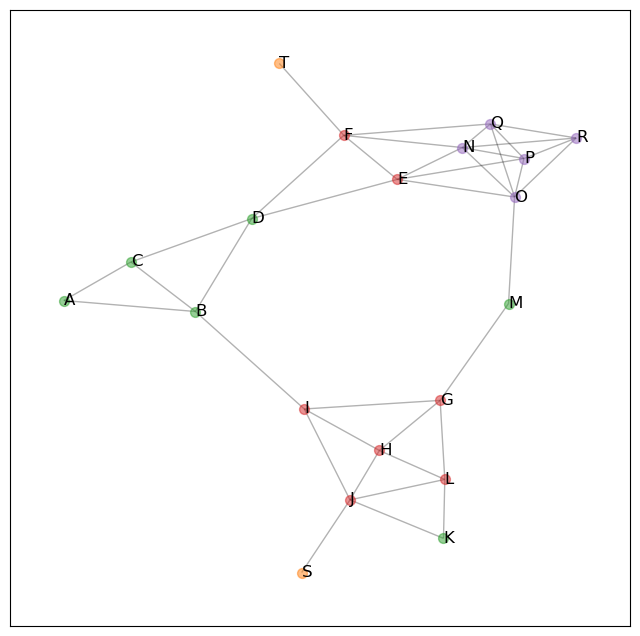

In [12]:
plt.figure(figsize=(8,8))
#pos=nx.kamada_kawai_layout(G)
pos=nx.spring_layout(G, k=0.5)

# Visualize the graph with communities
pos = nx.spring_layout(G)
for core_number, community in communities.items():
    nx.draw_networkx_nodes(G, pos, nodelist=community, node_color=f"C{core_number}", node_size=50,
                           alpha=0.5)
nx.draw_networkx_edges(G, pos, alpha=0.3)
nx.draw_networkx_labels(G, pos, horizontalalignment='left')
plt.show()

In [13]:
### Minimum nodes or edges to remove in order to disconnect a graph
# You can define nodes you want to have in different components
print(nx.minimum_node_cut(G, s='H', t='Q' ))
print(nx.minimum_edge_cut(G, s='H', t='Q'))

{'O', 'D'}
{('I', 'B'), ('M', 'O')}


### Subgraphs

In [14]:
### Observe data structure of communities list
print(cts)

[[2, ['A', 'B', 'C', 'D', 'M', 'K']], [3, ['E', 'F', 'G', 'H', 'I', 'L', 'J']], [4, ['P', 'N', 'O', 'Q', 'R']], [1, ['T', 'S']]]


In [15]:
ln = []
for el in cts:
    if el[0] > 2:
        ln += el[1]
kcG = nx.subgraph(G, ln)
naf.basic_graph_properties(kcG)

{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 12,
 'number_of_edges': 24,
 '------': '------',
 'is connected': False,
 'components': 2,
 'density': 0.36363636363636365}


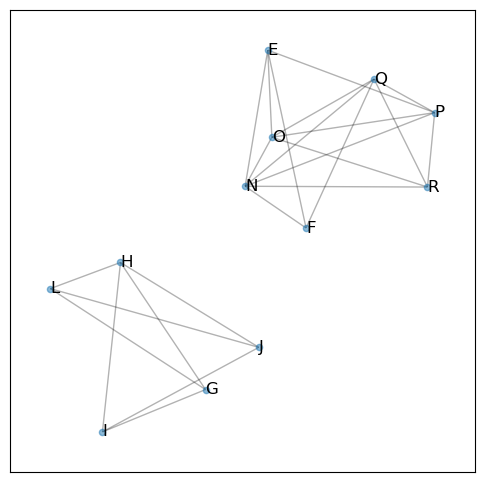

In [16]:

plt.figure(figsize=(6,6))

# Visualize the graph with communities
pos = nx.spring_layout(kcG, k=1.5)
#pos = nx.fruchterman_reingold_layout(kcG)

nx.draw_networkx_nodes(kcG, pos, node_size=20,alpha=0.5)
nx.draw_networkx_edges(kcG, pos, alpha=0.3)
nx.draw_networkx_labels(kcG, pos, horizontalalignment='left')
plt.show()

In [ ]:
### Onion layers: Returns the layer of each vertex in an onion decomposition of the graph.
# The onion decomposition refines the k-core decomposition by providing information 
# on the internal organization of each k-shell. It is usually used alongside the core numbers.
# https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.core.onion_layers.html
pprint.pprint(nx.onion_layers(G))

{'A': 2,
 'B': 4,
 'C': 3,
 'D': 5,
 'E': 7,
 'F': 6,
 'G': 6,
 'H': 7,
 'I': 6,
 'J': 6,
 'K': 2,
 'L': 6,
 'M': 2,
 'N': 8,
 'O': 8,
 'P': 8,
 'Q': 8,
 'R': 8,
 'S': 1,
 'T': 1}


In [47]:
# Identify communities based on onion layers
onion_layers = nx.onion_layers(G)
ol_dict = {}
for node, layer_number in onion_layers.items():
    if layer_number not in ol_dict:
        ol_dict[layer_number] = [node]
    else:
        ol_dict[layer_number].append(node)

# Print the communities
l_ol = []
for layer_number, layer_nodes in ol_dict.items():
    l_ol.append([layer_number,layer_nodes])
    print(f"Layer {layer_number}: {layer_nodes}")

Layer 1: ['T', 'S']
Layer 2: ['A', 'M', 'K']
Layer 3: ['C']
Layer 4: ['B']
Layer 5: ['D']
Layer 6: ['F', 'G', 'I', 'L', 'J']
Layer 7: ['H', 'E']
Layer 8: ['P', 'N', 'O', 'Q', 'R']


Nodes degree:  [('N', 6), ('O', 6), ('E', 5), ('F', 5), ('P', 5), ('Q', 5), ('J', 5), ('B', 4), ('D', 4), ('G', 4), ('H', 4), ('I', 4), ('L', 4), ('R', 4), ('C', 3), ('A', 2), ('M', 2), ('K', 2), ('T', 1), ('S', 1)]


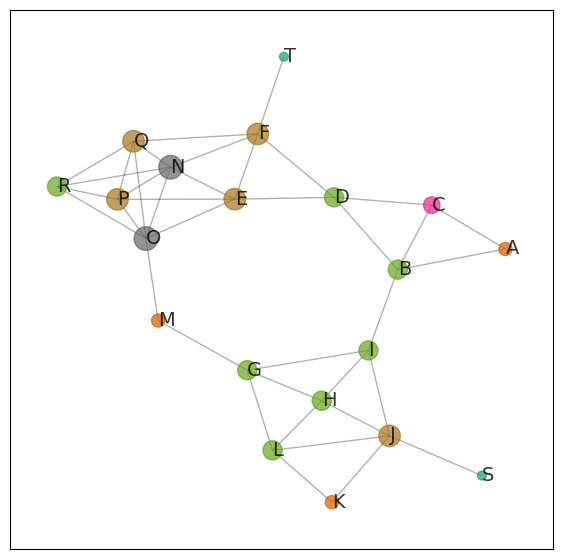

In [50]:

plt.figure(figsize=(7,7))
pos=nx.kamada_kawai_layout(G)
#pos=nx.spring_layout(G, k=0.5)

ld = list(nx.degree(G))
n_size = [n[1]*50-10 for n in ld]

colors = [n[1] for n in ld]
print('Nodes degree: ', sorted(ld, key=lambda x: x[1], reverse=True))

### https://matplotlib.org/stable/users/explain/colors/colormaps.html
nx.draw_networkx_nodes(G, pos, node_color=colors, cmap=plt.get_cmap('Dark2'), node_size=n_size,alpha=0.7)
nx.draw_networkx_edges(G, pos, alpha=0.3)
nx.draw_networkx_labels(G, pos, horizontalalignment='left', font_size=14, alpha=0.8)
plt.show()


### Betweenness

In [22]:
lb = list(nx.betweenness_centrality(G).items())
pprint.pprint(sorted(lb, key=lambda tup: tup[1], reverse=True))


[('B', 0.2688109161793373),
 ('I', 0.26237816764132554),
 ('D', 0.2541910331384016),
 ('G', 0.23411306042884988),
 ('O', 0.23343079922027285),
 ('M', 0.21656920077972708),
 ('J', 0.16374269005847952),
 ('F', 0.16130604288499029),
 ('E', 0.10799220272904483),
 ('L', 0.0705653021442495),
 ('H', 0.03547758284600389),
 ('N', 0.03518518518518518),
 ('Q', 0.02709551656920078),
 ('C', 0.02631578947368421),
 ('P', 0.008089668615984405),
 ('A', 0.0),
 ('T', 0.0),
 ('K', 0.0),
 ('S', 0.0),
 ('R', 0.0)]


In [23]:
### Plot betweenness density distribution 
betweenness_s = pd.Series([b[1] for b in lb])
stats = betweenness_s.describe()

# Format decimal values
stats = stats.apply(lambda x: format(x, '.20f'))

print(stats)

count    20.00000000000000000000
mean      0.10526315789473686402
std       0.10607122702863588937
min       0.00000000000000000000
25%       0.00606725146198830445
50%       0.05302144249512669161
75%       0.22078460038986352787
max       0.26881091617933727811
dtype: object


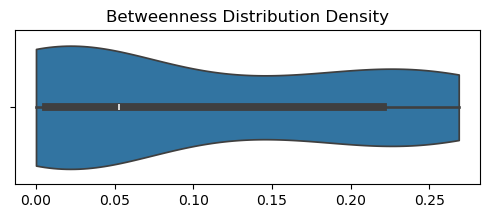

In [24]:
# Plot the distribution of betweenness density

plt.figure(figsize=(6, 2))
p = sns.violinplot(data=betweenness_s, orient='h', cut=0)
plt.title('Betweenness Distribution Density')
plt.show()

[10.0, 278.81091617933726, 36.315789473684205, 264.19103313840156, 117.99220272904483, 171.3060428849903, 18.089668615984408, 45.18518518518518, 243.43079922027286, 10.0, 37.09551656920078, 244.11306042884988, 45.47758284600389, 272.37816764132555, 80.5653021442495, 226.56920077972708, 173.74269005847952, 10.0, 10.0, 10.0]
20
20


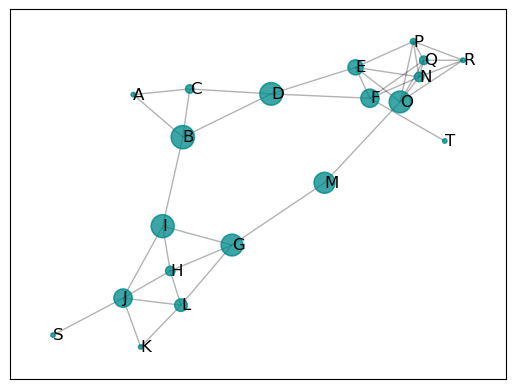

In [25]:

# Visualize the graph with betweenness values
pos = nx.spring_layout(G)

node_size = [b[1]*1000+10 for b in lb]
print(node_size)
print(len(node_size))
print(len(G.nodes))

for core_number, community in communities.items():
    nx.draw_networkx_nodes(G, pos, node_color='darkCyan', node_size=node_size,
                           alpha=0.3)


nx.draw_networkx_edges(G, pos, alpha=0.3)
nx.draw_networkx_labels(G, pos, horizontalalignment='left')
plt.show()

### Eigenvector

In [26]:
le = list(nx.eigenvector_centrality(G).items())
pprint.pprint(sorted(le, key=lambda tup: tup[1], reverse=True))


[('N', 0.43861503811730246),
 ('O', 0.4059242376223862),
 ('P', 0.39068365413260325),
 ('Q', 0.38024624915383354),
 ('E', 0.34211456663015255),
 ('R', 0.3323148651691344),
 ('F', 0.2809382264162027),
 ('D', 0.14694616017873952),
 ('M', 0.08932840208903875),
 ('T', 0.057791255211662576),
 ('B', 0.04743853639131925),
 ('C', 0.043850009892562124),
 ('G', 0.028321434198471933),
 ('I', 0.021030924734794006),
 ('A', 0.018779187340153634),
 ('H', 0.015032048537150176),
 ('L', 0.012276120978472011),
 ('J', 0.011433823374362384),
 ('K', 0.004878668828855451),
 ('S', 0.002352725088285219)]


In [27]:
### Plot eigenvector density distribution 
eigenvector_s = pd.Series([e[1] for e in le])
stats = eigenvector_s.describe()

# Format decimal values
stats = stats.apply(lambda x: format(x, '.20f'))

print(stats)

count    20.00000000000000000000
mean      0.15351480670427411490
std       0.16680655080708672866
min       0.00235272508828521893
25%       0.01784240263940277058
50%       0.05261489580149091017
75%       0.33476479053438890077
max       0.43861503811730245816
dtype: object


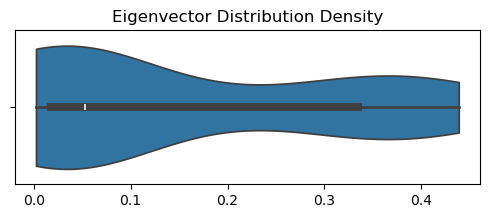

In [28]:
# Plot the distribution of eigenvector density

plt.figure(figsize=(6, 2))
p = sns.violinplot(data=eigenvector_s, orient='h', cut=0)
plt.title('Eigenvector Distribution Density')
plt.show()

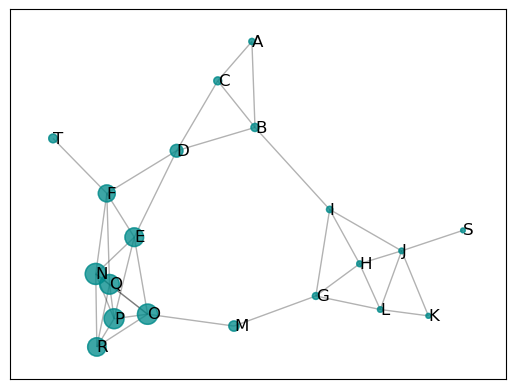

In [29]:

# Visualize the graph with eigenvector centrality
pos = nx.spring_layout(G)

node_size = [e[1]*500+10 for e in le]

for core_number, community in communities.items():
    nx.draw_networkx_nodes(G, pos, node_color='darkCyan', node_size=node_size,
                           alpha=0.3)


nx.draw_networkx_edges(G, pos, alpha=0.3)
nx.draw_networkx_labels(G, pos, horizontalalignment='left')
plt.show()